In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("system_monitoring_dataset_v2.csv")
df.head()

,timestamp,service_name,log_level,response_time_ms,cpu_usage_percent,memory_usage_mb,region,anomaly_type
0,2025-01-01 00:00:00,PaymentGateway,CRITICAL,2684.28,30.95,1045.10,eu-west-1,Normal
1,2025-01-01 00:05:00,UserAPI,INFO,1576.21,91.53,4372.13,us-east-1,Normal
2,2025-01-01 00:10:00,UserAPI,WARNING,433.45,61.48,13350.82,us-east-1,Normal
3,2025-01-01 00:15:00,UserAPI,WARNING,2052.72,40.36,12110.04,ap-south-1,Normal
4,2025-01-01 00:20:00,NotificationService,INFO,1167.97,29.52,3102.82,ap-south-1,Normal


In [7]:
print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)


DATASET SHAPE
(200, 8)

COLUMN NAMES
Index(['timestamp', 'service_name', 'log_level', 'response_time_ms',
       'cpu_usage_percent', 'memory_usage_mb', 'region', 'anomaly_type'],
      dtype='object')


In [8]:
print("\n==============================")
print("MISSING VALUES")
print("==============================")

print(df.isnull().sum())


MISSING VALUES
timestamp            0
service_name         0
log_level            0
response_time_ms     0
cpu_usage_percent    0
memory_usage_mb      0
region               0
anomaly_type         0
dtype: int64


In [9]:
duplicates = df.duplicated().sum()

print("\nDUPLICATE ROWS:", duplicates)

df = df.drop_duplicates()

print("\nAFTER REMOVING DUPLICATES")
print(df.shape)


DUPLICATE ROWS: 0

AFTER REMOVING DUPLICATES
(200, 8)


In [11]:
features = [
    'response_time_ms',
    'cpu_usage_percent',
    'memory_usage_mb'
]

X = df[features]

print("\nSELECTED FEATURES")
print(X.head())


SELECTED FEATURES
   response_time_ms  cpu_usage_percent  memory_usage_mb
0           2684.28              30.95          1045.10
1           1576.21              91.53          4372.13
2            433.45              61.48         13350.82
3           2052.72              40.36         12110.04
4           1167.97              29.52          3102.82


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFEATURES SCALED SUCCESSFULLY")


FEATURES SCALED SUCCESSFULLY


In [22]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [23]:
predictions = model.predict(X_scaled)

df['anomaly_prediction'] = predictions

# Convert labels

df['prediction_label'] = df['anomaly_prediction'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

print(df[['anomaly_prediction', 'prediction_label']].head())

   anomaly_prediction prediction_label
0                   1           Normal
1                   1           Normal
2                   1           Normal
3                   1           Normal
4                   1           Normal


In [24]:
print(df['prediction_label'].value_counts())

prediction_label
Normal     190
Anomaly     10
Name: count, dtype: int64


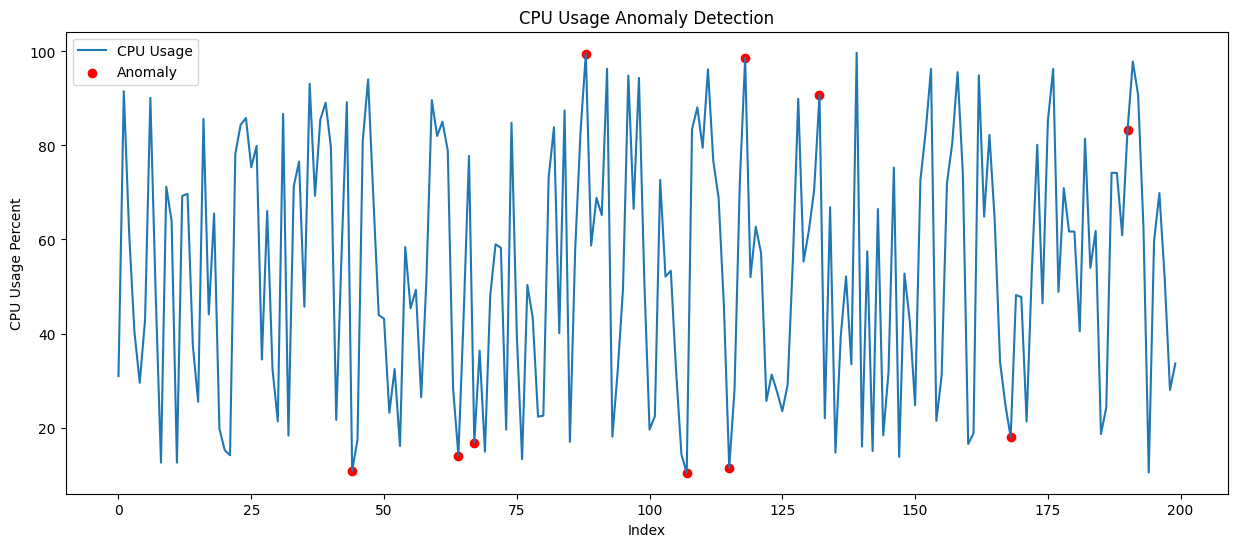

In [25]:
plt.figure(figsize=(15,6))

# Plot CPU usage

plt.plot(
    df['cpu_usage_percent'],
    label='CPU Usage'
)

# Get anomaly rows

anomalies = df[df['anomaly_prediction'] == -1]

# Plot anomalies

plt.scatter(
    anomalies.index,
    anomalies['cpu_usage_percent'],
    color='red',
    label='Anomaly'
)

plt.title("CPU Usage Anomaly Detection")

plt.xlabel("Index")

plt.ylabel("CPU Usage Percent")

plt.legend()

plt.show()

In [26]:
joblib.dump(model, 'isolation_forest_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("\nMODEL SAVED SUCCESSFULLY")


MODEL SAVED SUCCESSFULLY


In [27]:
df.to_csv(
    'system_monitoring_predictions.csv',
    index=False
)

print("\nOUTPUT CSV SAVED")


OUTPUT CSV SAVED


In [30]:
live_data = pd.DataFrame([{
    'response_time_ms': 300,
    'cpu_usage_percent': 10,
    'memory_usage_mb': 9000
}])

# Scale

live_scaled = scaler.transform(live_data)

# Predict

live_prediction = model.predict(live_scaled)

if live_prediction[0] == -1:
    print("\nALERT: ANOMALY DETECTED")
else:
    print("\nSYSTEM NORMAL")


# ============================================================
# STEP 14 — FINAL RESULT
# ============================================================

print("\n==============================")
print("FINAL RESULT")
print("==============================")

print("""
✔ Dataset Loaded
✔ Missing Values Checked
✔ Duplicates Removed
✔ Features Selected
✔ Features Scaled
✔ Isolation Forest Trained
✔ Anomalies Predicted
✔ Graph Generated
✔ Model Saved
✔ Real-Time Prediction Done
""")


ALERT: ANOMALY DETECTED

FINAL RESULT

✔ Dataset Loaded
✔ Missing Values Checked
✔ Duplicates Removed
✔ Features Selected
✔ Features Scaled
✔ Isolation Forest Trained
✔ Anomalies Predicted
✔ Graph Generated
✔ Model Saved
✔ Real-Time Prediction Done

